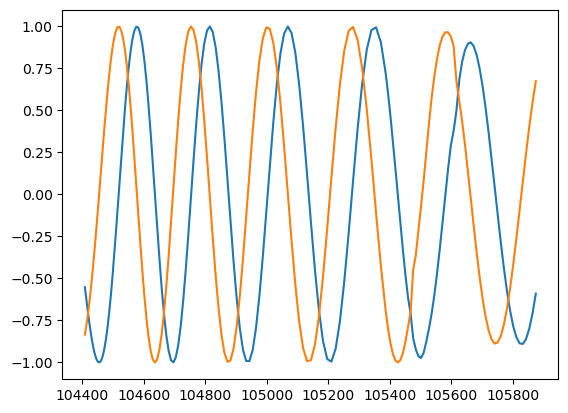

In [ ]:
from funcs import load_matrices
import numpy as np
import matplotlib.pyplot as plt
import os

# dirs = [n for n in os.listdir() if (os.path.isdir(n) and ((n[-2:]=='_p') or (n[-2:]=='_s')))]
dir = 'H_test_3'
smats_file = np.load(f'{dir}/Smatrix.npz', allow_pickle=True)['arr_0'][()]
r, hls, ddrls = load_matrices(dir)
n = len(hls[-1])
es = np.array([float(k.split('=')[-1]) for k in smats_file.keys()])
smats = [smats_file[f'E = {es[ei]}'] for ei in range(len(es))]
smats_el_0 = np.array([smats[i][0,0,0] for i in range(len(es))])
thres = np.real(np.diag(hls[-1]))[1:]
n1 = np.argwhere(es>thres[0])[0,0]
n2 = np.argwhere(es>thres[1])[0,0]
plt.plot(es[n1-100:n1+100],np.real(smats_el_0[n1-100:n1+100]))
plt.plot(es[n1-100:n1+100],np.imag(smats_el_0[n1-100:n1+100]))
plt.show()
# smats_el_0 = np.array([smats[i][0,0,0] for i in range(len(es))])

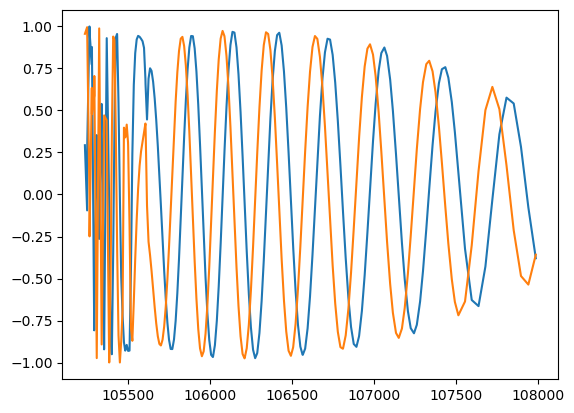

In [35]:
smats_el_1 = np.array([smats[i][0,1,1] for i in range(n1, len(es))])
plt.plot(es[n1:],np.real(smats_el_1))
plt.plot(es[n1:],np.imag(smats_el_1))
plt.show()

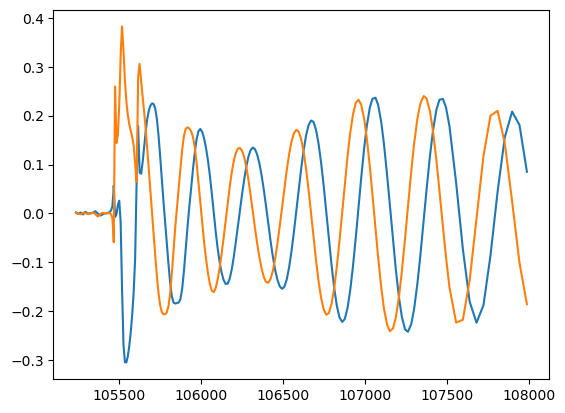

In [38]:
smats_inel_01 = np.array([smats[i][0,0,1] for i in range(n1, len(es))])
plt.plot(es[n1:],np.real(smats_inel_01))
plt.plot(es[n1:],np.imag(smats_inel_01))
plt.show()

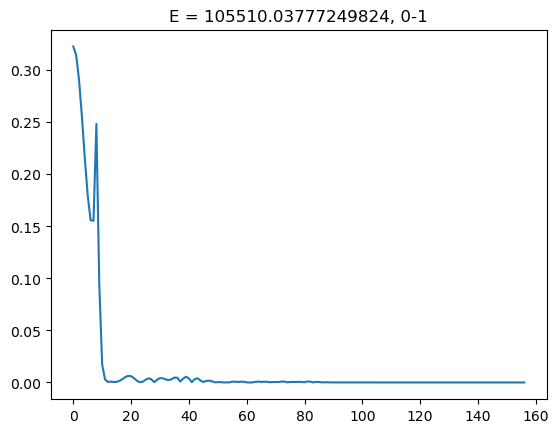

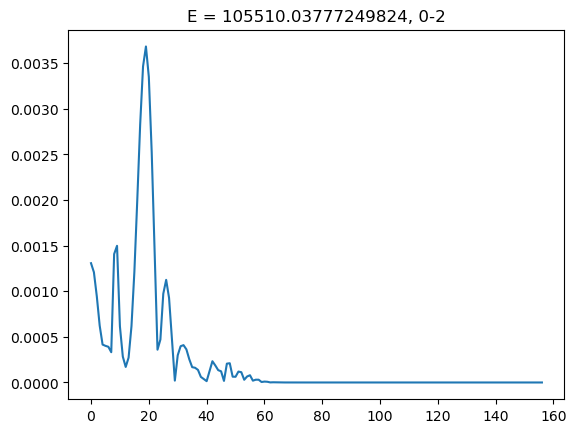

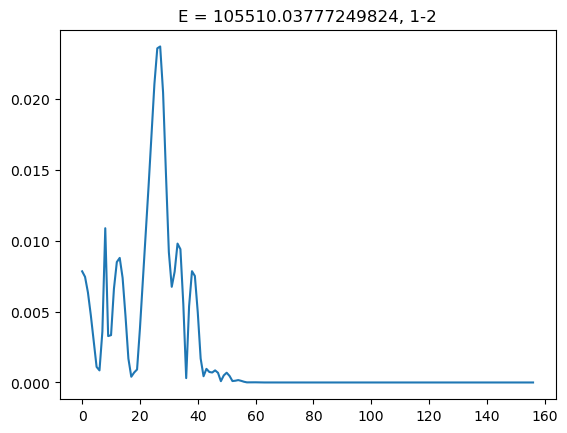

In [49]:
for i in range(n):
    for j in range(i+1,n):
        plt.plot(np.abs(smats[n2+20][:,i,j]))
        plt.title(f'E = {es[n2+20]}, {i}-{j}')
        plt.show()

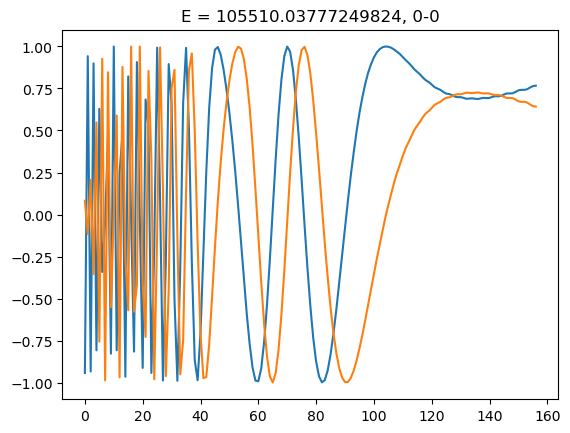

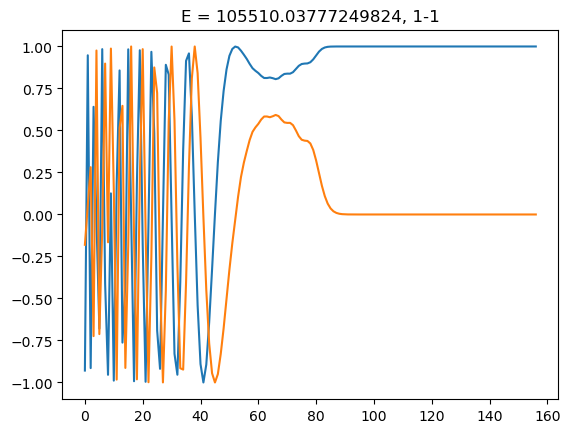

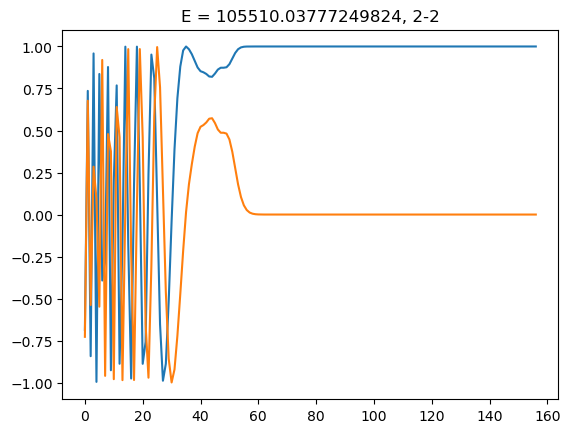

In [51]:
for i in range(n):
    plt.plot(np.real(smats[n2+20][:,i,i]))
    plt.plot(np.imag(smats[n2+20][:,i,i]))
    plt.title(f'E = {es[n2+20]}, {i}-{i}')
    plt.show()
        

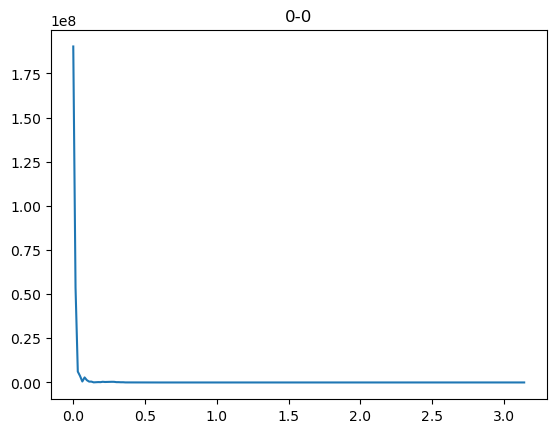

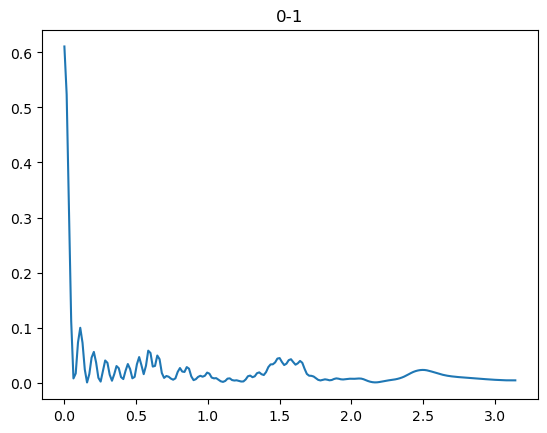

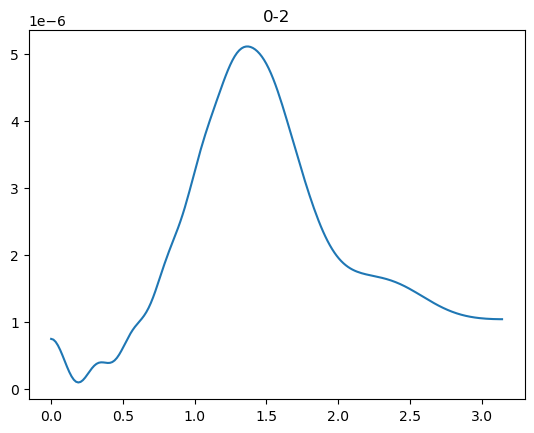

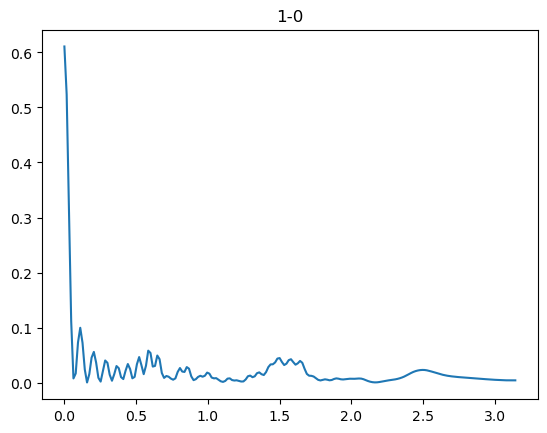

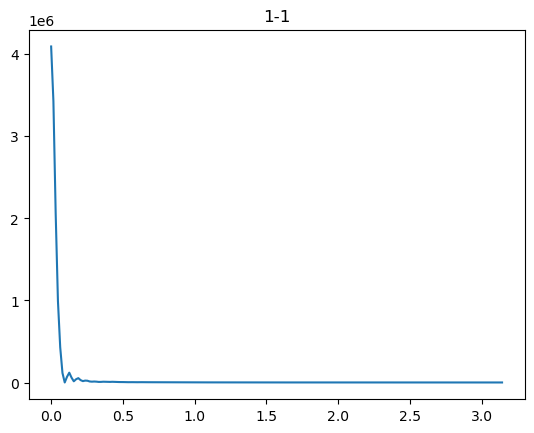

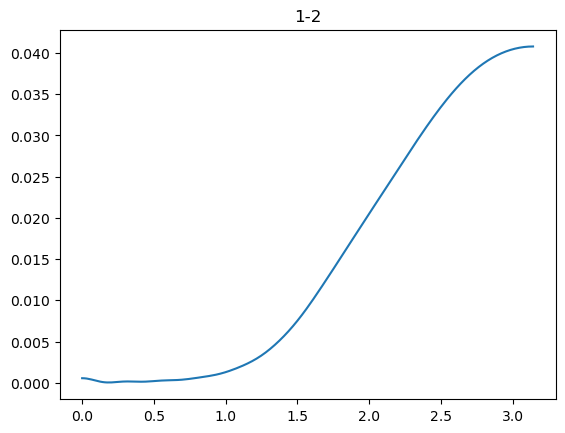

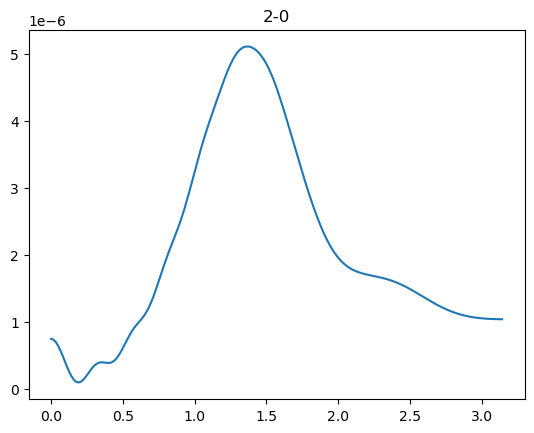

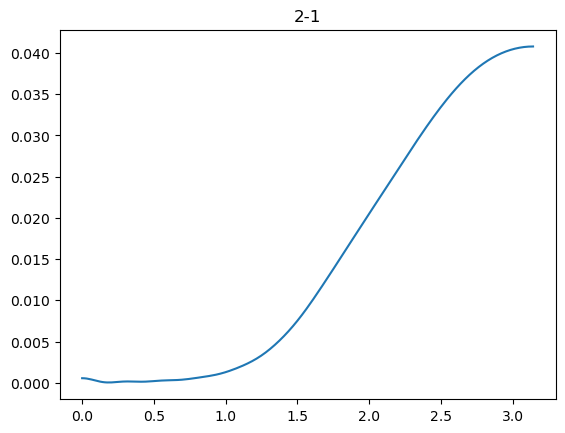

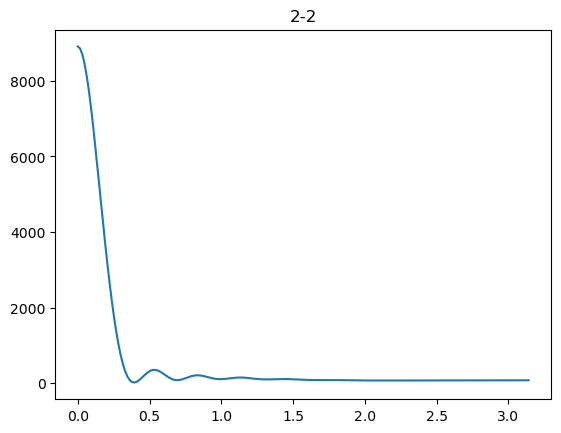

In [69]:
from scipy.special import eval_legendre
th = np.linspace(0,np.pi,200)
f = np.zeros((len(th),n,n),dtype=complex)
for i in range(n):
    for j in range(n):
        if i == j:
            f[:,i,j] = np.sum(np.array([(smats[n2][l,i,j]-1)*(2*l+1)*eval_legendre(l,np.cos(th)) for l in range(len(smats[n2]))]),axis=0)
        else:
            f[:,i,j] = np.sum(np.array([(smats[n2][l,i,j])*(2*l+1)*eval_legendre(l,np.cos(th)) for l in range(len(smats[n2]))]),axis=0)
for i in range(n):
    for j in range(n):
        plt.plot(th,np.abs(f[:,i,j])**2)
        plt.title(f'{i}-{j}')
        plt.show()